In [43]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
hr = pd.read_csv('heart.csv')

In [45]:
#sttistical summary of the dataset
summary = hr.describe().T
summary.round(3) #rounding the summary to 2 decimal places 
summary

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [46]:
correlation_with_target = hr.corr()['target']
print(correlation_with_target)


age        -0.229324
sex        -0.279501
cp          0.434854
trestbps   -0.138772
chol       -0.099966
fbs        -0.041164
restecg     0.134468
thalach     0.422895
exang      -0.438029
oldpeak    -0.438441
slope       0.345512
ca         -0.382085
thal       -0.337838
target      1.000000
Name: target, dtype: float64


In [47]:
                                    #check for missing values
hr.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

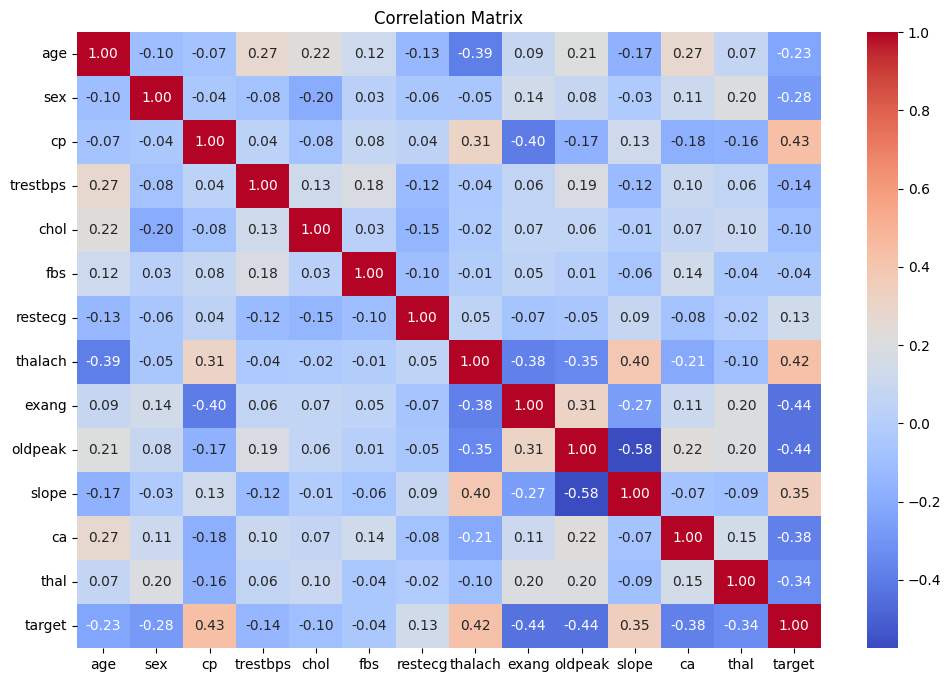

In [48]:
#Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(hr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

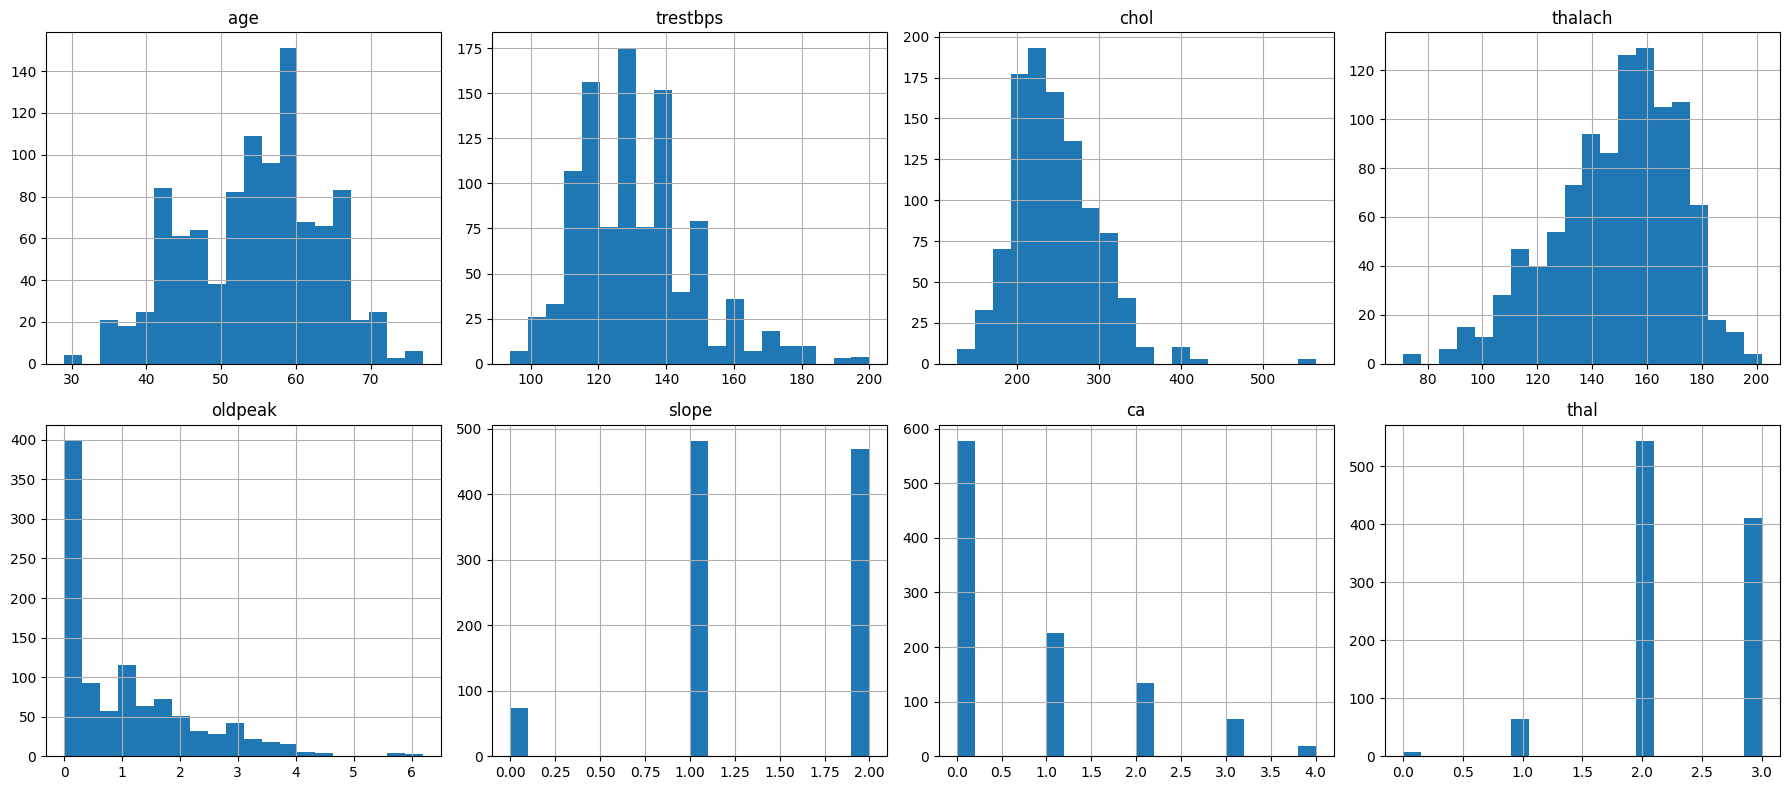

In [49]:
# Create subplots for the distribution of numerical features
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Plot histograms for each numerical feature
hr.hist(ax=axes.flatten(), column=['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'slope', 'ca', 'thal'], bins=20)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

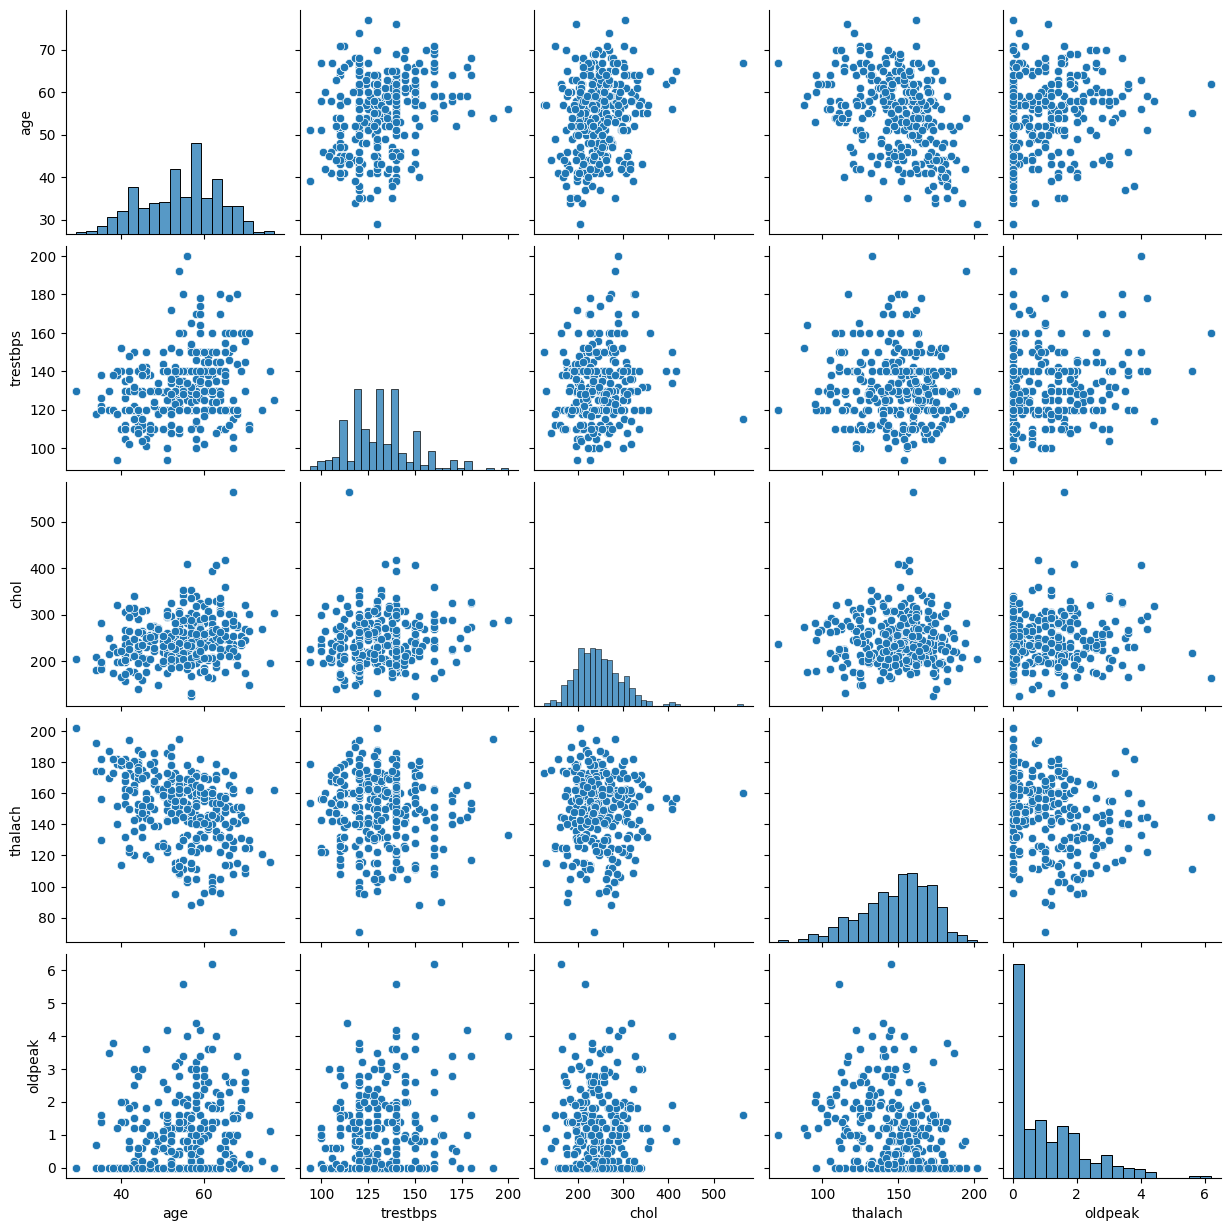

In [50]:
# Plot scatter plots to visualize relationships between numerical features
sns.pairplot(hr[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']])
plt.show()

Data Preprocessing

In [74]:
#Spliting the datA  
from sklearn.model_selection import train_test_split
X = hr.drop('target', axis=1)
y = hr['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [75]:
#Feaure scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model Creation

In [76]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_leaf=1, min_samples_split=2, random_state=42)
dt.fit(X_train, y_train)
# Predicting the test set results
y_pred = dt.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {accuracy:.2f}%")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 98.54%
[[102   0]
 [  3 100]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [77]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(max_depth=20, max_features='log2', min_samples_leaf=1, min_samples_split=2, n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf) * 100
print(f"Random Forest Accuracy: {accuracy_rf:.2f}%")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 98.54%
[[102   0]
 [  3 100]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [78]:
#support vector machine
from sklearn.svm import SVC
svm = SVC(kernel='rbf', C=50, gamma='scale')
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {accuracy:.2f}%")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 98.54%
[[102   0]
 [  3 100]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



Hyperparameter tuning

In [56]:

from sklearn.model_selection import GridSearchCV
#decision tree hyperparameter tuning
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Score: {best_score:.2f}")


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score: 0.98


In [57]:
#random forest hyperparameter tuning
param_grid = {
    'n_estimators': [10, 50,  100],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2) 
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Score: {best_score:.2f}")


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Score: 0.98


In [58]:
# SVM hyperparameter tuning
param_grid = {
    'C': [1, 10, 50],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}
grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Score: {best_score:.2f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'C': 50, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score: 0.98


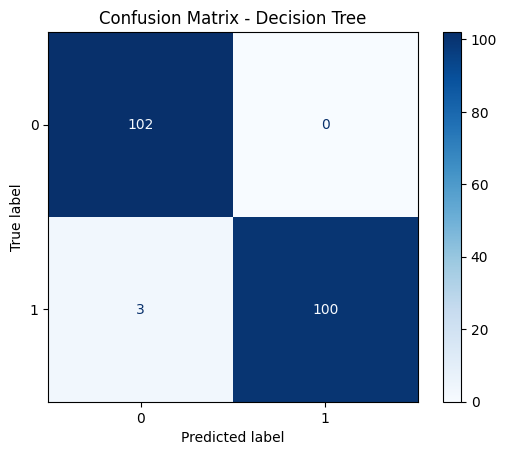

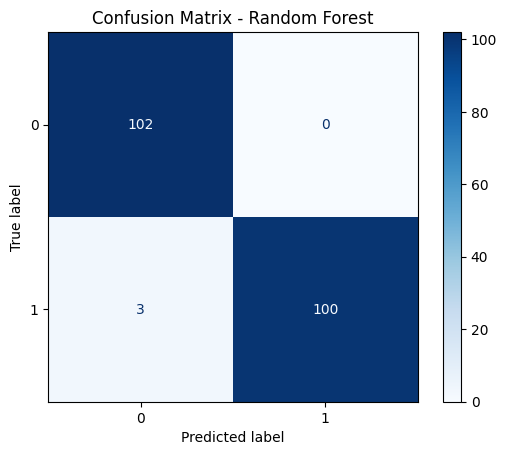

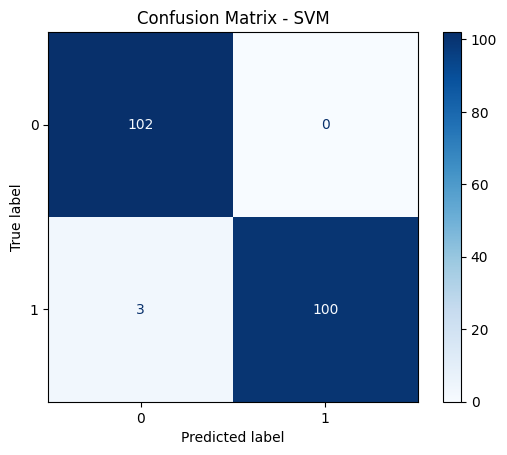

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models = {'Decision Tree': dt, 'Random Forest': rf, 'SVM': svm}

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()


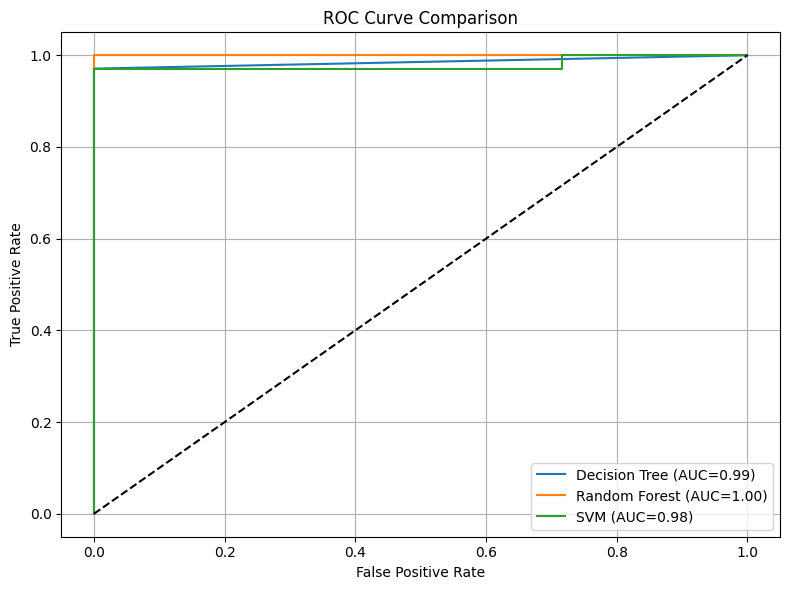

In [60]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Example: assuming you have predicted probabilities already
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt.predict_proba(X_test)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
# For SVM, use decision_function and min-max scale to [0, 1]
svm_scores = svm.decision_function(X_test)
svm_scores = (svm_scores - svm_scores.min()) / (svm_scores.max() - svm_scores.min())
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_scores)

auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(8,6))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC={auc_svm:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


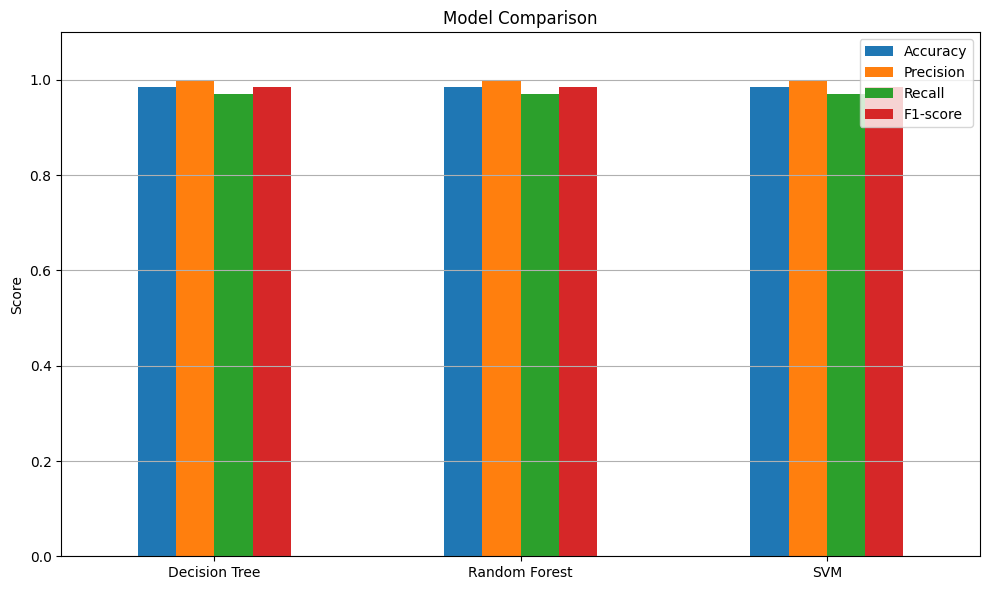

In [61]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred)
    }

df_results = pd.DataFrame(results).T

df_results.plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


In [79]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Feature selection to get best 5 features
selector_5 = SelectKBest(k=5, score_func=mutual_info_classif)
X_new_5 = selector_5.fit_transform(X, y)
selected_features_5 = X.columns[selector_5.get_support()]
print("Top 5 selected features:", selected_features_5.tolist())

Top 5 selected features: ['cp', 'chol', 'thalach', 'oldpeak', 'thal']


Decision tree after feature selection with top5 features

In [82]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Decision Tree with top 5 selected features

# Select top 5 features for train and test sets
X_train_5 = selector_5.transform(X_train)
X_test_5 = selector_5.transform(X_test)

dt_5 = DecisionTreeClassifier(random_state=42)
dt_5.fit(X_train_5, y_train)
y_pred_5 = dt_5.predict(X_test_5)

accuracy_5 = accuracy_score(y_test, y_pred_5) * 100
print(f"Accuracy (Top 5 features): {accuracy_5:.2f}%")
print(confusion_matrix(y_test, y_pred_5))
print(classification_report(y_test, y_pred_5))

Accuracy (Top 5 features): 100.00%
[[102   0]
 [  0 103]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       102
           1       1.00      1.00      1.00       103

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(


In [83]:
#random forest on top 5 selected features
rf_5 = RandomForestClassifier(max_depth=None, max_features='sqrt', min_samples_leaf=1, min_samples_split=2, n_estimators=50)
rf_5.fit(X_train_5, y_train)
y_pred_5 = rf_5.predict(X_test_5)
accuracy_5 = accuracy_score(y_test, y_pred_5) * 100
print(f"Accuracy (Top 5 features): {accuracy_5:.2f}%")
print(confusion_matrix(y_test, y_pred_5))
print(classification_report(y_test, y_pred_5))

Accuracy (Top 5 features): 97.07%
[[102   0]
 [  6  97]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       102
           1       1.00      0.94      0.97       103

    accuracy                           0.97       205
   macro avg       0.97      0.97      0.97       205
weighted avg       0.97      0.97      0.97       205



In [84]:
#SVM on top 5 selected features
svm_5 = SVC(C= 50, gamma= 'scale', kernel='rbf')
svm_5.fit(X_train_5, y_train)
y_pred_5 = svm_5.predict(X_test_5)
accuracy_5 = accuracy_score(y_test, y_pred_5) * 100
print(f"Accuracy (Top 5 features): {accuracy_5:.2f}%")
print(confusion_matrix(y_test, y_pred_5))
print(classification_report(y_test, y_pred_5))


Accuracy (Top 5 features): 87.32%
[[85 17]
 [ 9 94]]
              precision    recall  f1-score   support

           0       0.90      0.83      0.87       102
           1       0.85      0.91      0.88       103

    accuracy                           0.87       205
   macro avg       0.88      0.87      0.87       205
weighted avg       0.88      0.87      0.87       205



In [85]:
#Feature selection to get best 3 features
selector_3 = SelectKBest(k=3, score_func=mutual_info_classif)
X_new_3 = selector_3.fit_transform(X, y)
selected_features_3 = X.columns[selector_3.get_support()]
print("Top 3 selected features:", selected_features_3.tolist())

Top 3 selected features: ['chol', 'thalach', 'oldpeak']


In [88]:
# Decision tree with top 3 features

# Select top 3 features for train and test sets
X_train_3 = selector_3.transform(X_train)
X_test_3 = selector_3.transform(X_test)

dt_3 = DecisionTreeClassifier(criterion='gini', max_depth=20, min_samples_leaf=1, min_samples_split=2)
dt_3.fit(X_train_3, y_train)
y_pred_3 = dt_3.predict(X_test_3)
# Evaluate performance
accuracy_3 = accuracy_score(y_test, y_pred_3) * 100
print(f"Accuracy (Top 3 features): {accuracy_3:.2f}%")
print(confusion_matrix(y_test, y_pred_3))
print(classification_report(y_test, y_pred_3))

Accuracy (Top 3 features): 98.05%
[[102   0]
 [  4  99]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       102
           1       1.00      0.96      0.98       103

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205



C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(


In [90]:
#random forest on top 3 selected features
rf_3 = RandomForestClassifier(max_depth=20, max_features='sqrt', min_samples_leaf=2, min_samples_split=5, n_estimators=50)
rf_3.fit(X_train_3, y_train)
y_pred_3 = rf_3.predict(X_test_3)
accuracy_3 = accuracy_score(y_test, y_pred_3) * 100
print(f"Accuracy (Top 3 features): {accuracy_3:.2f}%")
print(confusion_matrix(y_test, y_pred_3))
print(classification_report(y_test, y_pred_3))

Accuracy (Top 3 features): 98.54%
[[102   0]
 [  3 100]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [91]:
#svm on top 3 selected features
svm_3 = SVC(C= 50, gamma= 'scale', kernel='rbf')
svm_3.fit(X_train_3, y_train)
y_pred_3 = svm_3.predict(X_test_3)
accuracy_3 = accuracy_score(y_test, y_pred_3) * 100
print(f"Accuracy (Top 3 features): {accuracy_3:.2f}%")
print(confusion_matrix(y_test, y_pred_3))   
print(classification_report(y_test, y_pred_3))

Accuracy (Top 3 features): 70.24%
[[65 37]
 [24 79]]
              precision    recall  f1-score   support

           0       0.73      0.64      0.68       102
           1       0.68      0.77      0.72       103

    accuracy                           0.70       205
   macro avg       0.71      0.70      0.70       205
weighted avg       0.71      0.70      0.70       205



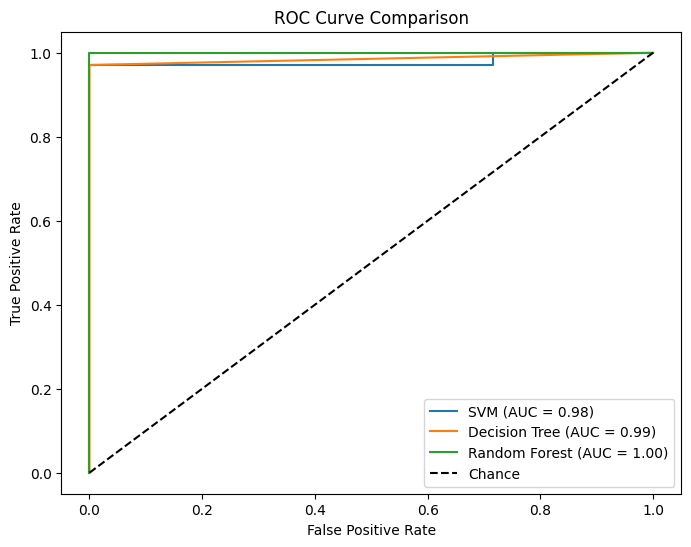

In [ ]:
#roc curve


C:\Users\hp\AppData\Local\Temp\ipykernel_23452\1224524703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')


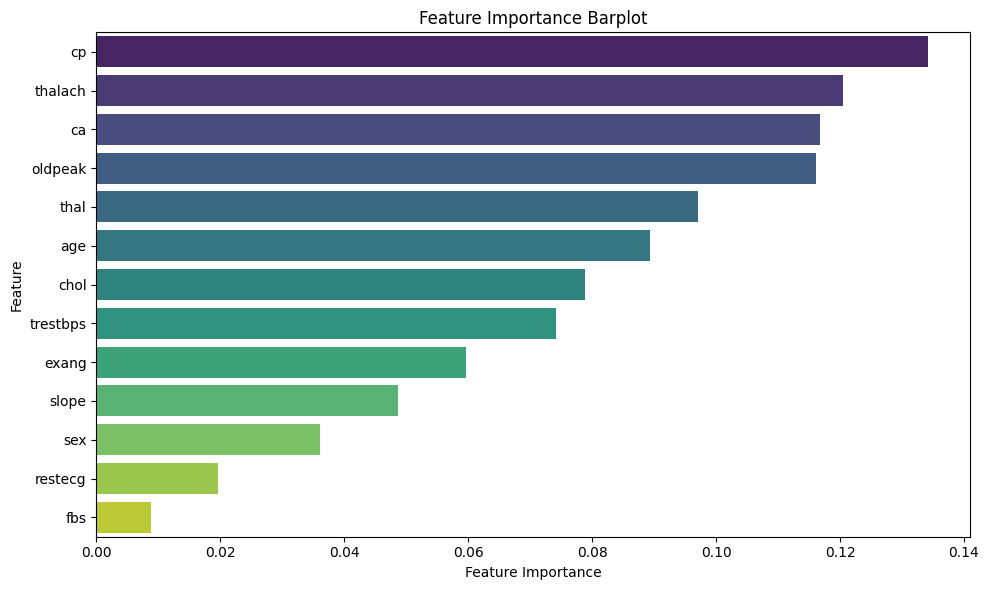

In [ ]:
# Plot feature importance as a barplot
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance Barplot')
plt.tight_layout()
plt.show()